# Movie Dataset — Correlation Analysis
**Dataset:** 7,512 movies (1980–2020) with budget, gross, score, votes, runtime, genre, rating, company, director, star, and more.

**Goal:** Understand which features correlate with box-office gross revenue.

## 1. Setup & Data Loading

In [65]:
# ── Imports ──────────────────────────────────────────────────────────────────
# Core data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
plt.style.use('ggplot')                          # consistent, clean plot style
matplotlib.rcParams['figure.figsize'] = (12, 8)  # default figure size
%matplotlib inline

# Suppress pandas chained-assignment warnings (safe for EDA)
pd.options.mode.chained_assignment = None

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [66]:
# ── Load data ────────────────────────────────────────────────────────────────
# Use a relative path so the notebook works on any machine.
# Place movies.csv in the same directory as this notebook.
df = pd.read_csv('movies.csv')

print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

Dataset loaded: 7,668 rows × 15 columns


## 2. Initial Data Inspection

In [67]:
# ── First look at the data ───────────────────────────────────────────────────
# head() shows the first 5 rows
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [68]:
# ── Shape and data types ─────────────────────────────────────────────────────
# info() combines shape, non-null counts, and dtypes in one call
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   object 
 1   rating    7591 non-null   object 
 2   genre     7668 non-null   object 
 3   year      7668 non-null   int64  
 4   released  7666 non-null   object 
 5   score     7665 non-null   float64
 6   votes     7665 non-null   float64
 7   director  7668 non-null   object 
 8   writer    7665 non-null   object 
 9   star      7667 non-null   object 
 10  country   7665 non-null   object 
 11  budget    5497 non-null   float64
 12  gross     7479 non-null   float64
 13  company   7651 non-null   object 
 14  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), object(9)
memory usage: 898.7+ KB


In [69]:
# ── Descriptive statistics for numeric columns ───────────────────────────────
# describe() gives count, mean, std, min, quartiles, and max
df.describe()

,year,score,votes,budget,gross,runtime
count,7668.000000,7665.000000,7.665000e+03,5.497000e+03,7.479000e+03,7664.000000
mean,2000.405451,6.390411,8.810850e+04,3.558988e+07,7.850054e+07,107.261613
std,11.153508,0.968842,1.633238e+05,4.145730e+07,1.657251e+08,18.581247
min,1980.000000,1.900000,7.000000e+00,3.000000e+03,3.090000e+02,55.000000
25%,1991.000000,5.800000,9.100000e+03,1.000000e+07,4.532056e+06,95.000000
50%,2000.000000,6.500000,3.300000e+04,2.050000e+07,2.020576e+07,104.000000
75%,2010.000000,7.100000,9.300000e+04,4.500000e+07,7.601669e+07,116.000000
max,2020.000000,9.300000,2.400000e+06,3.560000e+08,2.847246e+09,366.000000


## 3. Data Quality Checks

### 3.1 Missing Values

In [70]:
# ── Missing data percentage per column ──────────────────────────────────────
missing = (df.isnull().mean() * 100).round(1)
missing = missing[missing > 0]  # show only columns that have gaps

if missing.empty:
    print('No missing values found.')
else:
    print('Columns with missing data (%):')
    print(missing.sort_values(ascending=False).to_string())

Columns with missing data (%):
budget     28.3
gross       2.5
rating      1.0
company     0.2
runtime     0.1


In [71]:
# ── Replace zero budgets with NaN ─────────────────────────────────────────────
# ~28% of rows have budget = 0.0, which almost certainly means data is missing
# rather than the film having no cost. Replacing with NaN prevents these zeros
# from distorting budget-related correlations and calculations.
df['budget'] = df['budget'].replace(0, np.nan)

print(f"Rows with missing budget: {df['budget'].isna().sum():,}")
print(f"Rows with known budget  : {df['budget'].notna().sum():,}")

Rows with missing budget: 2,171
Rows with known budget  : 5,497


### 3.2 Duplicate Rows

In [72]:
# ── Check and remove duplicate rows ─────────────────────────────────────────
n_before = len(df)
df = df.drop_duplicates()  # inplace via reassignment to keep the df clean
n_after = len(df)

print(f'Rows before: {n_before:,}')
print(f'Rows after : {n_after:,}')
print(f'Duplicates removed: {n_before - n_after:,}')

Rows before: 7,668
Rows after : 7,668
Duplicates removed: 0


### 3.3 Outlier Detection — Gross Revenue

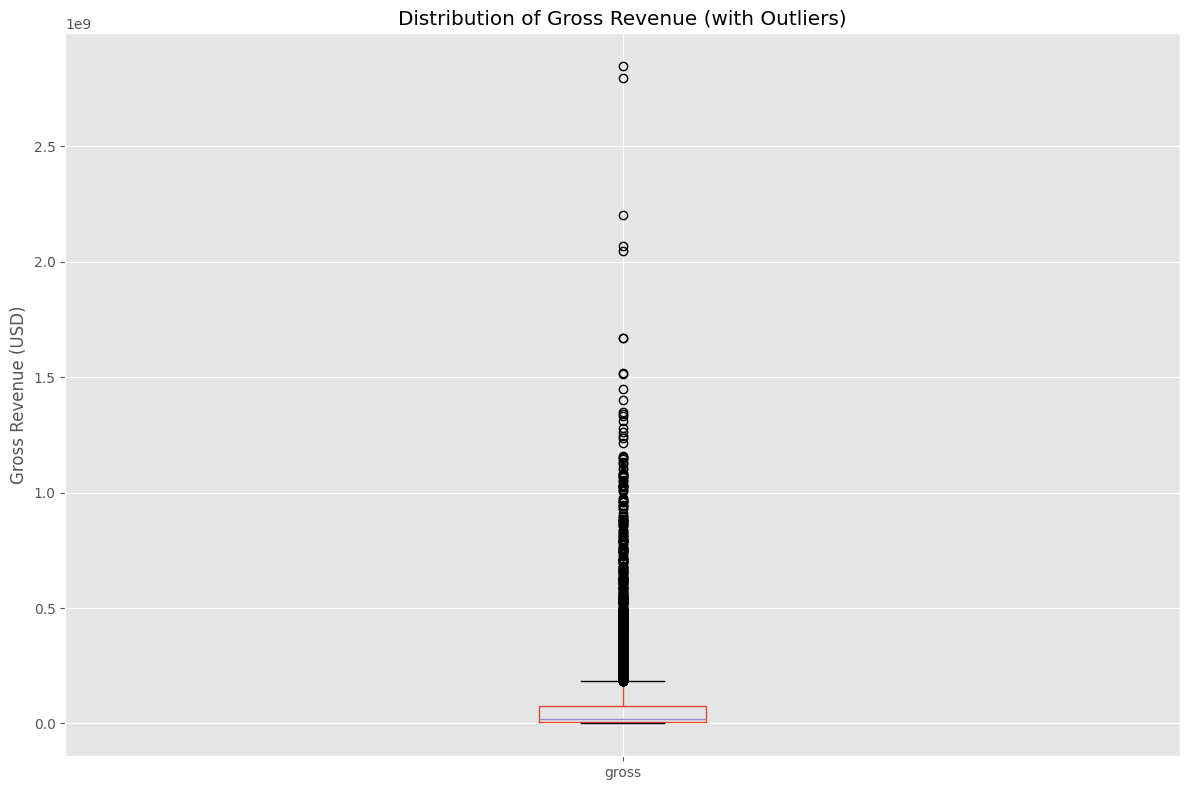

In [73]:
# ── Box plot to visualise outliers in the gross column ───────────────────────
# A long upper whisker and many points above it signal extreme blockbusters
fig, ax = plt.subplots()
df.boxplot(column=['gross'], ax=ax)
ax.set_title('Distribution of Gross Revenue (with Outliers)')
ax.set_ylabel('Gross Revenue (USD)')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [74]:
# ── Extract release year from the 'released' date string ─────────────────────
# The existing 'year' column reflects the catalogue year;
# 'release_year' reflects the actual theatrical release date.
# Keeping both allows us to detect mismatches (e.g. late-year releases).
df['release_year'] = pd.to_datetime(df['released'], errors='coerce').dt.year

# Preview the relevant columns side-by-side
df[['name', 'year', 'released', 'release_year']].head(10)

/tmp/ipykernel_3444/4237882380.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['release_year'] = pd.to_datetime(df['released'], errors='coerce').dt.year


,name,year,released,release_year
0,The Shining,1980,"June 13, 1980 (United States)",NaN
1,The Blue Lagoon,1980,"July 2, 1980 (United States)",NaN
2,Star Wars: Episode V - The Empire Strikes Back,1980,"June 20, 1980 (United States)",NaN
3,Airplane!,1980,"July 2, 1980 (United States)",NaN
4,Caddyshack,1980,"July 25, 1980 (United States)",NaN
5,Friday the 13th,1980,"May 9, 1980 (United States)",NaN
6,The Blues Brothers,1980,"June 20, 1980 (United States)",NaN
7,Raging Bull,1980,"December 19, 1980 (United States)",NaN
8,Superman II,1980,"June 19, 1981 (United States)",NaN
9,The Long Riders,1980,"May 16, 1980 (United States)",NaN


## 5. Exploratory Visualisations

### 5.1 Budget vs Gross Revenue

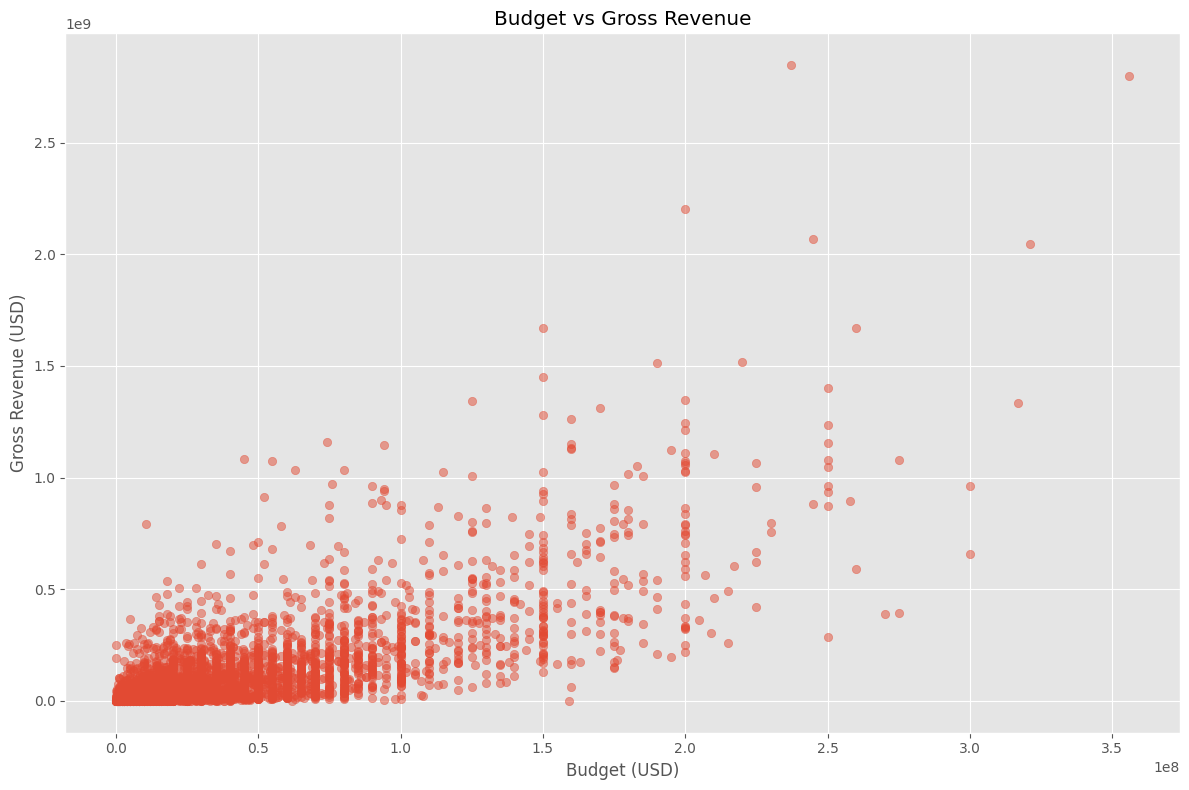

In [75]:
# ── Scatter plot: budget vs gross ────────────────────────────────────────────
# Alpha transparency reveals point density in crowded regions
plt.scatter(x=df['budget'], y=df['gross'], alpha=0.5)
plt.title('Budget vs Gross Revenue')
plt.xlabel('Budget (USD)')
plt.ylabel('Gross Revenue (USD)')
plt.tight_layout()
plt.show()

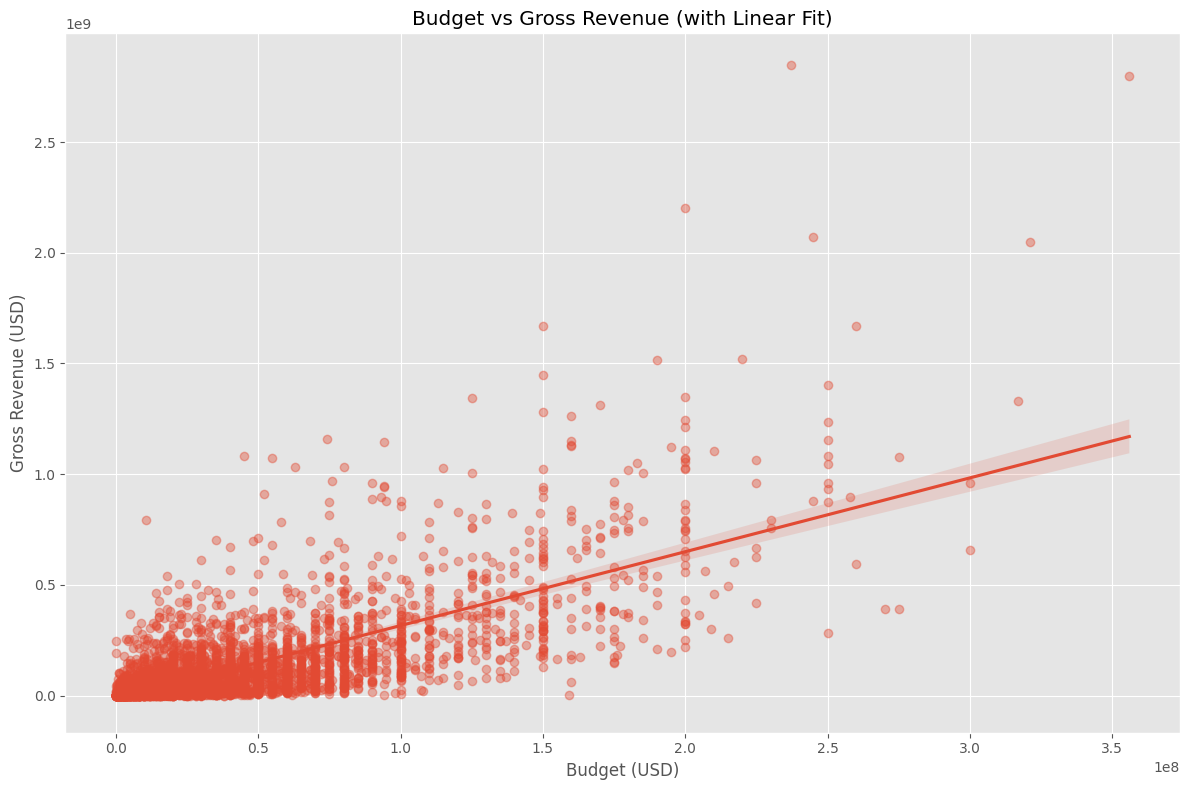

In [76]:
# ── Regression plot: budget vs gross ─────────────────────────────────────────
# regplot adds a linear fit and 95% confidence band
sns.regplot(x='budget', y='gross', data=df, scatter_kws={'alpha': 0.4})
plt.title('Budget vs Gross Revenue (with Linear Fit)')
plt.xlabel('Budget (USD)')
plt.ylabel('Gross Revenue (USD)')
plt.tight_layout()
plt.show()

### 5.2 IMDb Score vs Gross Revenue

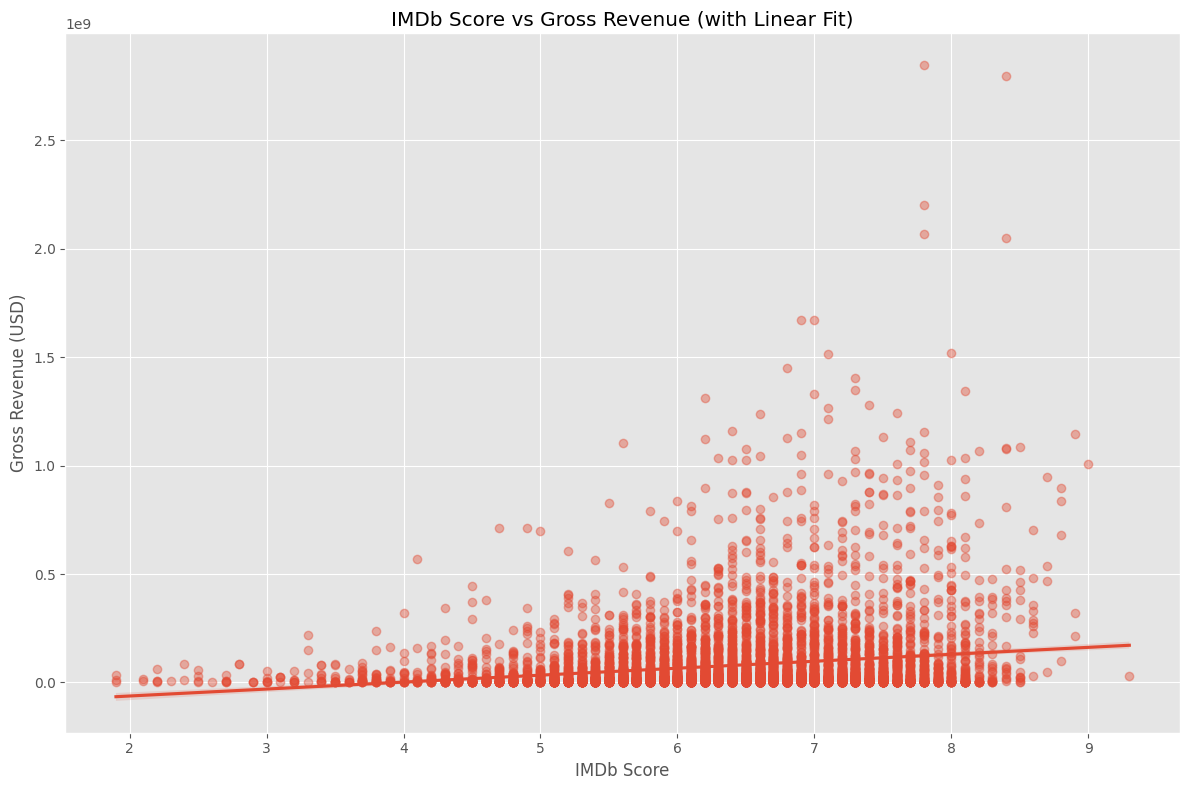

In [77]:
# ── Regression plot: IMDb score vs gross ─────────────────────────────────────
# Tests whether higher-rated films earn more — the relationship is weaker
# than budget, suggesting critical acclaim alone doesn't guarantee revenue.
sns.regplot(x='score', y='gross', data=df, scatter_kws={'alpha': 0.4})
plt.title('IMDb Score vs Gross Revenue (with Linear Fit)')
plt.xlabel('IMDb Score')
plt.ylabel('Gross Revenue (USD)')
plt.tight_layout()
plt.show()

### 5.3 Content Rating vs Gross Revenue

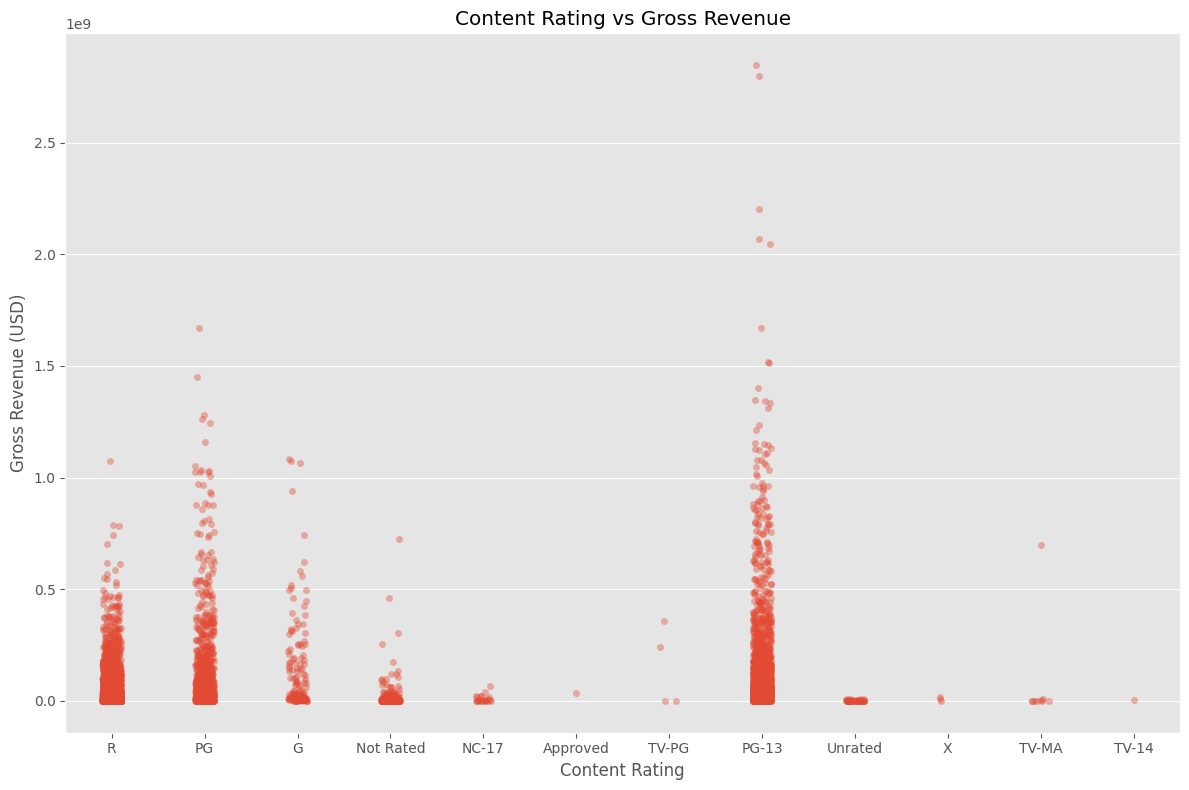

In [78]:
# ── Strip plot: content rating vs gross ──────────────────────────────────────
# stripplot shows every data point, revealing distributions per rating category.
# 'jitter=True' (default) spreads points horizontally to reduce overplotting.
sns.stripplot(x='rating', y='gross', data=df, alpha=0.4)
plt.title('Content Rating vs Gross Revenue')
plt.xlabel('Content Rating')
plt.ylabel('Gross Revenue (USD)')
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

### 6.1 Numeric Features Only (Pearson)

Pearson correlation measures **linear** relationships between continuous numeric features. Values close to ±1 indicate strong linear association; values near 0 indicate none.

In [79]:
# ── Sort movies by gross to observe top earners ───────────────────────────────
# Useful context before examining correlations
df.sort_values(by='gross', ascending=False, inplace=False).head(10)[['name', 'year', 'budget', 'gross', 'score', 'votes']]

,name,year,budget,gross,score,votes
5445,Avatar,2009,237000000.0,2.847246e+09,7.8,1100000.0
7445,Avengers: Endgame,2019,356000000.0,2.797501e+09,8.4,903000.0
3045,Titanic,1997,200000000.0,2.201647e+09,7.8,1100000.0
6663,Star Wars: Episode VII - The Force Awakens,2015,245000000.0,2.069522e+09,7.8,876000.0
7244,Avengers: Infinity War,2018,321000000.0,2.048360e+09,8.4,897000.0
7480,The Lion King,2019,260000000.0,1.670728e+09,6.9,222000.0
6653,Jurassic World,2015,150000000.0,1.670516e+09,7.0,593000.0
6043,The Avengers,2012,220000000.0,1.518816e+09,8.0,1300000.0
6646,Furious 7,2015,190000000.0,1.515341e+09,7.1,370000.0
7494,Frozen II,2019,150000000.0,1.450027e+09,6.8,148000.0


In [80]:
# ── Pearson correlation — numeric columns only ───────────────────────────────
# Older pandas version .corr() automatically selects numeric columns
# Newer pandas versions raise an error if non-numeric columns are present
numeric_corr = df.select_dtypes(include='number').corr(method='pearson')
numeric_corr

,year,score,votes,budget,gross,runtime,release_year
year,1.000000,0.097995,0.222945,0.329321,0.257486,0.120811,NaN
score,0.097995,1.000000,0.409182,0.076254,0.186258,0.399451,NaN
votes,0.222945,0.409182,1.000000,0.442429,0.630757,0.309212,NaN
budget,0.329321,0.076254,0.442429,1.000000,0.740395,0.320447,NaN
gross,0.257486,0.186258,0.630757,0.740395,1.000000,0.245216,NaN
runtime,0.120811,0.399451,0.309212,0.320447,0.245216,1.000000,NaN
release_year,NaN,NaN,NaN,NaN,NaN,NaN,NaN


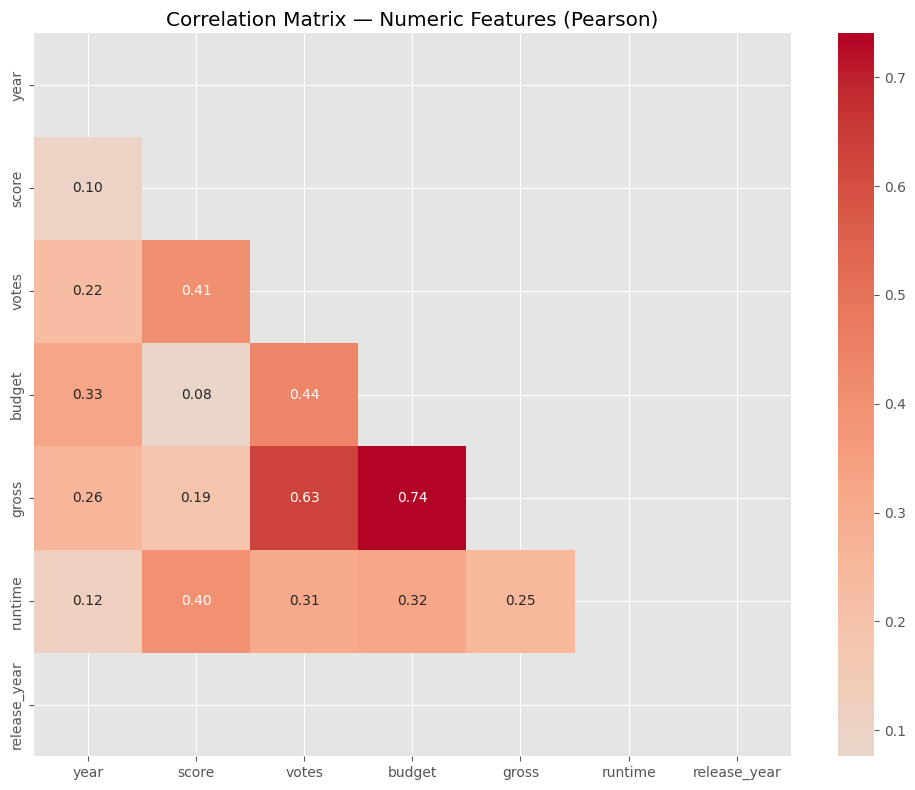

In [81]:
# ── Heatmap: numeric feature correlations ────────────────────────────────────
# fmt='.2f' shows two decimal places; mask the upper triangle to reduce clutter
mask = np.triu(np.ones_like(numeric_corr, dtype=bool))  # upper-triangle mask

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    numeric_corr,
    annot=True,
    fmt='.2f',
    mask=mask,
    cmap='coolwarm',
    center=0,
    ax=ax
)
ax.set_title('Correlation Matrix — Numeric Features (Pearson)')
plt.tight_layout()
plt.show()

### 6.2 All Features — Including Categorical (Pearson after Encoding)

To include categorical columns (genre, director, star, etc.) we convert each to integer codes. This is a simple label-encoding that allows correlation to be computed across the full dataset. Note: label-encoded correlations on nominal categories are approximate — use with caution.

In [82]:
# ── Label-encode all categorical columns on a copy ───────────────────────────
# We work on df_encoded (a true copy) to preserve the original df intact
df_encoded = df.copy()

# Convert every object/string column to integer category codes
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

print('Encoded dtypes:')
print(df_encoded.dtypes)

Encoded dtypes:
name              int16
rating             int8
genre              int8
year              int64
released          int16
score           float64
votes           float64
director          int16
writer            int16
star              int16
country            int8
budget          float64
gross           float64
company           int16
runtime         float64
release_year    float64
dtype: object


In [83]:
# ── Pearson correlation — all (encoded) features ─────────────────────────────
full_corr = df_encoded.corr(method='pearson')
full_corr

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,release_year
name,1.000000,-0.008069,0.016355,0.011453,-0.011311,0.017097,0.013088,0.009079,0.009081,0.006472,-0.010737,0.023970,0.005533,0.009211,0.010392,NaN
rating,-0.008069,1.000000,0.072423,0.008779,0.016613,-0.001314,0.033225,0.019483,-0.005921,0.013405,0.081244,-0.176002,-0.107339,-0.032943,0.062145,NaN
genre,0.016355,0.072423,1.000000,-0.081261,0.029822,0.027965,-0.145307,-0.015258,0.006567,-0.005477,-0.037615,-0.356564,-0.235650,-0.071067,-0.052711,NaN
year,0.011453,0.008779,-0.081261,1.000000,-0.000695,0.097995,0.222945,-0.020795,-0.008656,-0.027242,-0.070938,0.329321,0.257486,-0.010431,0.120811,NaN
released,-0.011311,0.016613,0.029822,-0.000695,1.000000,0.042788,0.016097,-0.001478,-0.002404,0.015777,-0.020427,0.014683,0.001659,-0.010474,0.000868,NaN
score,0.017097,-0.001314,0.027965,0.097995,0.042788,1.000000,0.409182,0.009559,0.019416,-0.001609,-0.133348,0.076254,0.186258,0.001030,0.399451,NaN
votes,0.013088,0.033225,-0.145307,0.222945,0.016097,0.409182,1.000000,0.000260,0.000892,-0.019282,0.073625,0.442429,0.630757,0.133204,0.309212,NaN
director,0.009079,0.019483,-0.015258,-0.020795,-0.001478,0.009559,0.000260,1.000000,0.299067,0.039234,0.017490,-0.012272,-0.014441,0.004404,0.017624,NaN
writer,0.009081,-0.005921,0.006567,-0.008656,-0.002404,0.019416,0.000892,0.299067,1.000000,0.027245,0.015343,-0.039451,-0.023519,0.005646,-0.003511,NaN
star,0.006472,0.013405,-0.005477,-0.027242,0.015777,-0.001609,-0.019282,0.039234,0.027245,1.000000,-0.012998,-0.019589,-0.002717,0.012442,0.010174,NaN


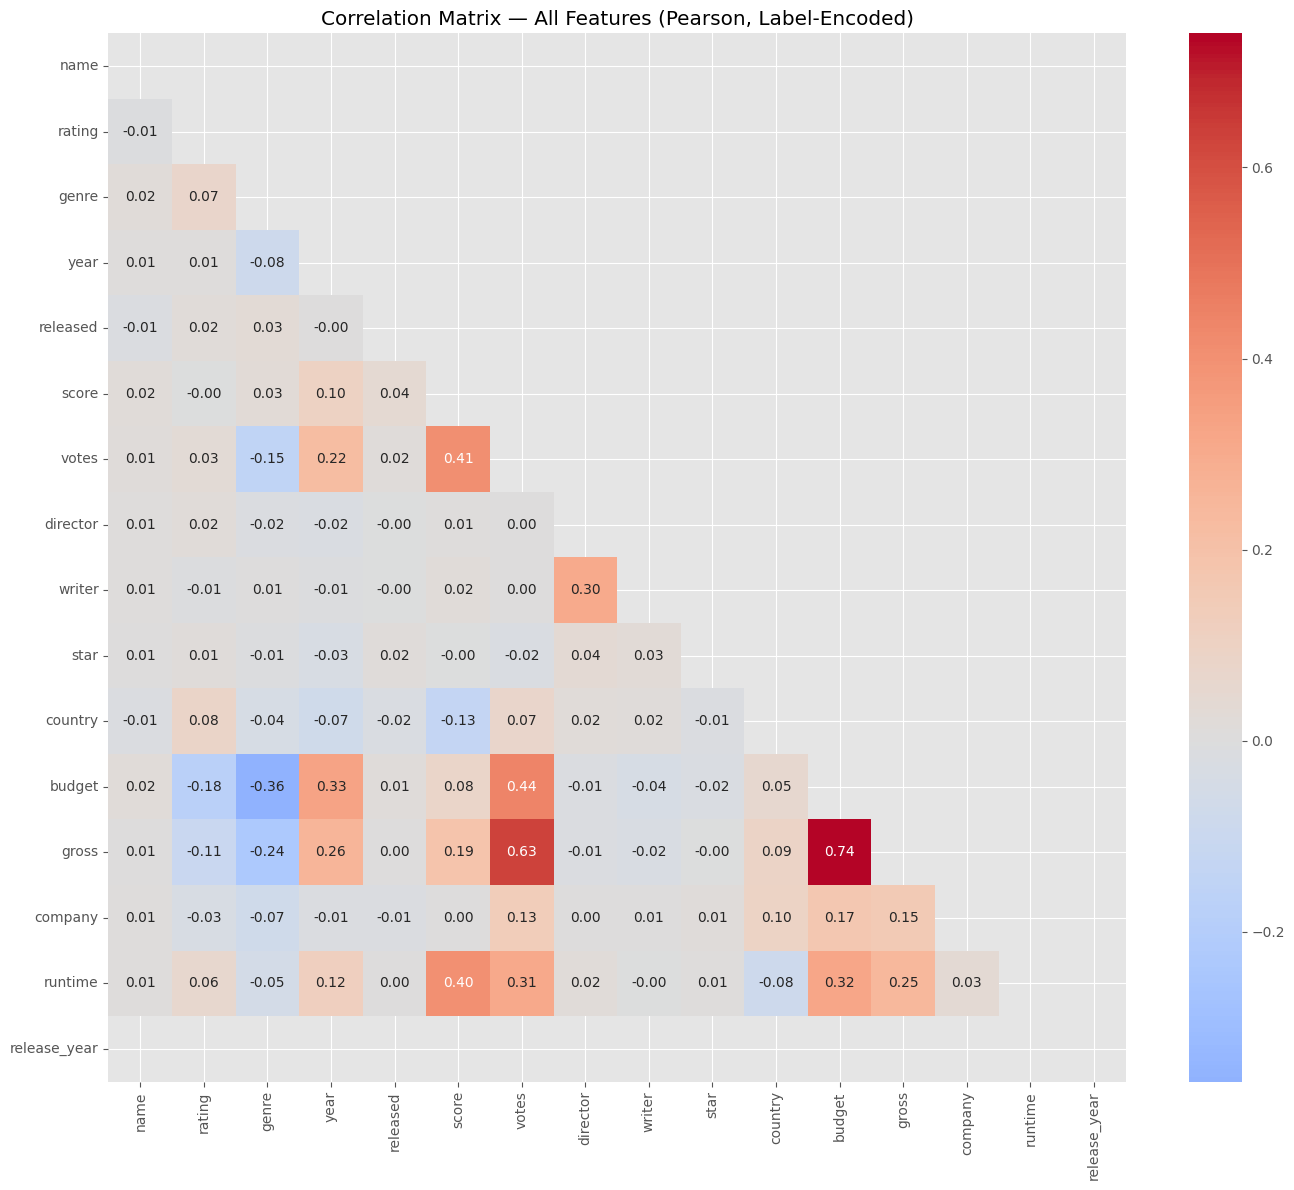

In [84]:
# ── Heatmap: all-feature correlations ────────────────────────────────────────
mask_full = np.triu(np.ones_like(full_corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    full_corr,
    annot=True,
    fmt='.2f',
    mask=mask_full,
    cmap='coolwarm',
    center=0,
    ax=ax
)
ax.set_title('Correlation Matrix — All Features (Pearson, Label-Encoded)')
plt.tight_layout()
plt.show()

### 6.3 Identifying Strongly Correlated Feature Pairs

In [85]:
# ── Unstack the correlation matrix into (feature_A, feature_B) pairs ─────────
# unstacking converts the square matrix to a Series of all pairwise values
corr_pairs = full_corr.unstack()

# ── Sort all pairs from most negative to most positive correlation ────────────
sorted_pairs = corr_pairs.sort_values(ascending=True)

# ── Filter: keep only pairs with |correlation| > 0.5, excluding self-pairs ────
# Self-pairs (budget-budget, etc.) always equal 1.0 and add no insight
strong_pairs = sorted_pairs[
    (abs(sorted_pairs) > 0.5) & (sorted_pairs < 1.0)
].drop_duplicates()  # each pair appears twice in an unmasked matrix

print('Strongly correlated feature pairs (|r| > 0.5):')
print(strong_pairs.to_string())

Strongly correlated feature pairs (|r| > 0.5):
votes   gross    0.630757
budget  gross    0.740395


## 7. Revenue Analysis

### 7.1 Top 15 Production Companies by Total Gross Revenue

In [86]:
# ── Aggregate gross revenue by company, take top 15 ─────────────────────────
company_gross = (
    df.groupby('company')['gross']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .astype('int64')  # convert float to integer for cleaner display
)

# Display as a formatted table
company_gross_df = company_gross.reset_index()
company_gross_df.columns = ['Company', 'Total Gross (USD)']
company_gross_df['Total Gross (USD)'] = company_gross_df['Total Gross (USD)'].map('${:,.0f}'.format)
company_gross_df

,Company,Total Gross (USD)
0,Warner Bros.,"$56,491,421,806"
1,Universal Pictures,"$52,514,188,890"
2,Columbia Pictures,"$43,008,941,346"
3,Paramount Pictures,"$40,493,607,415"
4,Twentieth Century Fox,"$40,257,053,857"
5,Walt Disney Pictures,"$36,327,887,792"
6,New Line Cinema,"$19,883,797,684"
7,Marvel Studios,"$15,065,592,411"
8,DreamWorks Animation,"$11,873,612,858"
9,Touchstone Pictures,"$11,795,832,638"


### 7.2 Top 15 Companies by Year

In [87]:
# ── Aggregate gross revenue by company AND year, take top 15 ─────────────────
# Useful for spotting which studios dominated in specific decades
company_year_gross = (
    df.groupby(['company', 'year'])['gross']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .astype('int64')
)

company_year_gross

company                year
Walt Disney Pictures   2019    5773131804
Marvel Studios         2018    4018631866
Universal Pictures     2015    3834354888
Twentieth Century Fox  2009    3793491246
Walt Disney Pictures   2017    3789382071
Paramount Pictures     2011    3565705182
Warner Bros.           2010    3300479986
                       2011    3223799224
Walt Disney Pictures   2010    3104474158
Paramount Pictures     2014    3071298586
Columbia Pictures      2006    2934631933
                       2019    2932757449
Marvel Studios         2019    2797501328
Warner Bros.           2018    2774168962
Columbia Pictures      2011    2738363306
Name: gross, dtype: int64

### 7.3 ROI Analysis

In [88]:
# ── Compute Return on Investment (ROI) ───────────────────────────────────────
# ROI = (gross - budget) / budget
# Only calculated for rows where budget is known (not NaN) to avoid division
# errors and misleading results from the zero-budget rows fixed above.
df_roi = df.dropna(subset=['budget', 'gross']).copy()
df_roi['roi'] = (df_roi['gross'] - df_roi['budget']) / df_roi['budget']

# ── Top 15 movies by ROI ──────────────────────────────────────────────────────
top_roi = (
    df_roi[['name', 'year', 'genre', 'budget', 'gross', 'roi']]
    .sort_values('roi', ascending=False)
    .head(15)
    .reset_index(drop=True)
)
top_roi['budget'] = top_roi['budget'].map('${:,.0f}'.format)
top_roi['gross']  = top_roi['gross'].map('${:,.0f}'.format)
top_roi['roi']    = top_roi['roi'].map('{:.1f}x'.format)
top_roi

,name,year,genre,budget,gross,roi
0,Paranormal Activity,2007,Horror,"$15,000","$193,355,800",12889.4x
1,The Blair Witch Project,1999,Horror,"$60,000","$248,639,099",4143.0x
2,The Gallows,2015,Horror,"$100,000","$42,964,410",428.6x
3,El Mariachi,1992,Action,"$7,000","$2,040,920",290.6x
4,Once,2007,Drama,"$150,000","$20,936,722",138.6x
5,Clerks,1994,Comedy,"$27,000","$3,151,130",115.7x
6,Napoleon Dynamite,2004,Comedy,"$400,000","$46,138,887",114.3x
7,In the Company of Men,1997,Comedy,"$25,000","$2,804,473",111.2x
8,Keeping Mum,2005,Comedy,"$169,000","$18,586,834",109.0x
9,Open Water,2003,Adventure,"$500,000","$54,683,487",108.4x


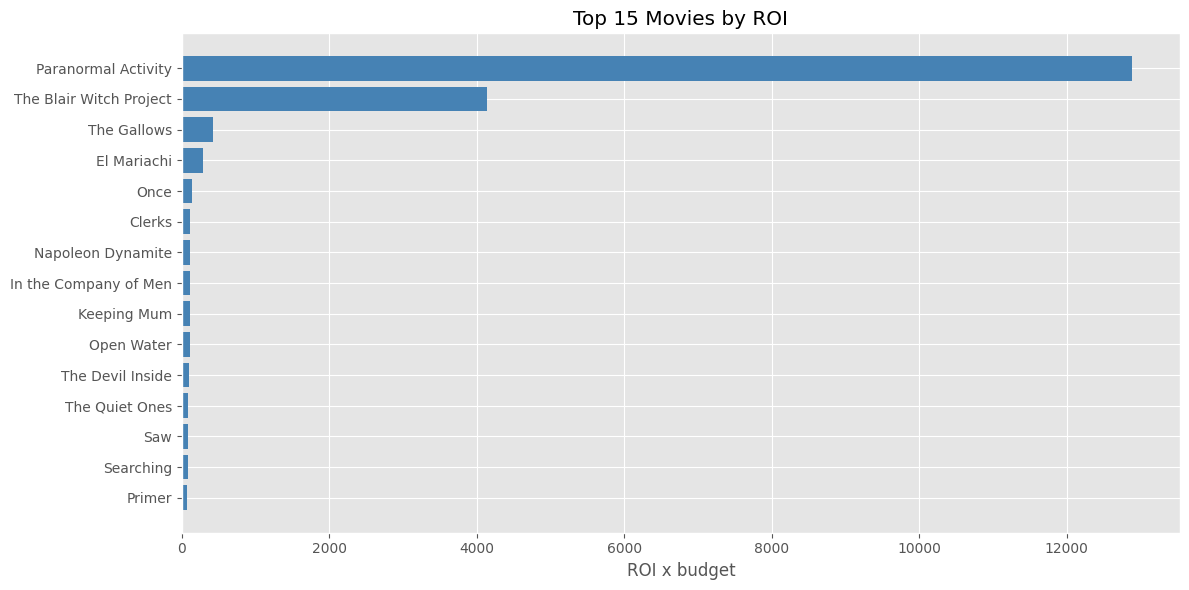

In [89]:
# ── Bar chart: Top 15 movies by ROI ──────────────────────────────────────────
df_roi_plot = (
    df_roi[['name', 'roi']]
    .sort_values('roi', ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
plt.barh(df_roi_plot['name'], df_roi_plot['roi'], color='steelblue')
plt.xlabel('ROI x budget')
plt.title('Top 15 Movies by ROI')
plt.gca().invert_yaxis()  # highest ROI at the top
plt.tight_layout()
plt.show()

### 7.4 Genre Breakdown Over Time

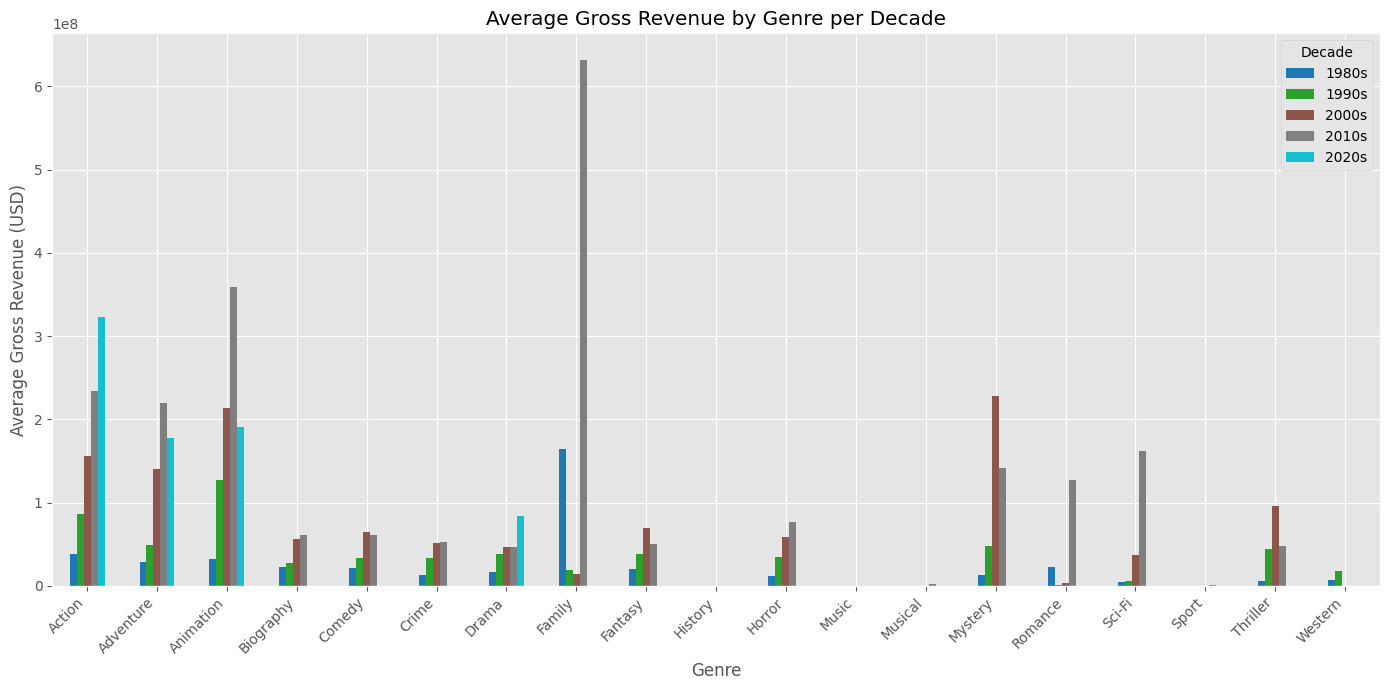

In [90]:
# ── Average gross per genre per decade ───────────────────────────────────────
# Grouping by decade (rather than individual year) smooths out yearly noise
# and makes trends easier to read across the 30-year dataset window.
df['decade'] = (df['year'] // 10 * 10).astype(str) + 's'  # e.g. 1990, 2000

genre_decade = (
    df.groupby(['decade', 'genre'])['gross']
    .mean()
    .reset_index()
)
genre_decade.columns = ['Decade', 'Genre', 'Avg Gross']

# ── Pivot for plotting ────────────────────────────────────────────────────────
genre_pivot = genre_decade.pivot(index='Genre', columns='Decade', values='Avg Gross')

genre_pivot.plot(kind='bar', figsize=(14, 7), colormap='tab10')
plt.title('Average Gross Revenue by Genre per Decade')
plt.xlabel('Genre')
plt.ylabel('Average Gross Revenue (USD)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Decade')
plt.tight_layout()
plt.show()

In [91]:
# ── Top 5 genres by average gross (overall) ───────────────────────────────────
# A simple ranking to complement the decade breakdown above
top_genres = (
    df.groupby('genre')['gross']
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)
top_genres.columns = ['Genre', 'Avg Gross (USD)']
top_genres['Avg Gross (USD)'] = top_genres['Avg Gross (USD)'].map('${:,.0f}'.format)
top_genres

,Genre,Avg Gross (USD)
0,Animation,"$239,229,987"
1,Family,"$196,172,492"
2,Action,"$145,508,581"
3,Adventure,"$109,325,230"
4,Mystery,"$101,183,528"
